***Proyecto 1 - Probabilidad y estadística***

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
df = pd.read_excel("visceral_fat.xlsx")
df.head()
df.info()
df.describe() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ethnicity                   133 non-null    int64  
 1   mean diastolic bp (mmhg)    133 non-null    float64
 2   mean systolic bp (mmhg)     133 non-null    float64
 3   central armellini fat (mm)  133 non-null    float64
 4   pregnancies (number)        128 non-null    float64
 5   bmi pregestational (kg/m)   132 non-null    float64
 6   child birth weight (g)      133 non-null    int64  
 7   gestational dm              133 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 8.4 KB


,ethnicity,mean diastolic bp (mmhg),mean systolic bp (mmhg),central armellini fat (mm),pregnancies (number),bmi pregestational (kg/m),child birth weight (g),gestational dm
count,133.000000,133.000000,133.000000,133.000000,128.000000,132.000000,133.000000,133.000000
mean,0.443609,70.593985,116.578947,44.230827,2.351562,27.871136,3257.563910,0.135338
std,0.498688,8.657662,13.879602,14.606195,1.686397,6.874268,490.318578,0.343378
min,0.000000,51.500000,90.000000,12.700000,1.000000,15.810000,1105.000000,0.000000
25%,0.000000,64.500000,107.000000,34.600000,1.000000,22.550000,2944.000000,0.000000
50%,0.000000,70.000000,114.000000,42.500000,2.000000,26.260000,3220.000000,0.000000
75%,1.000000,75.500000,125.000000,52.700000,3.000000,30.935000,3610.000000,0.000000
max,1.000000,100.500000,167.000000,94.400000,9.000000,55.360000,4534.000000,1.000000


*Análisis explororatorio*

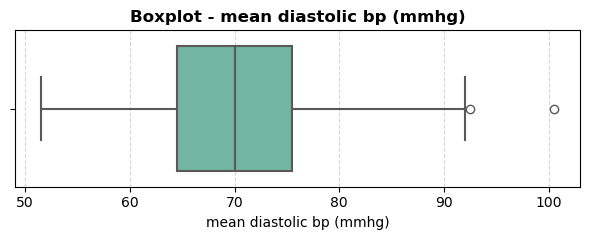

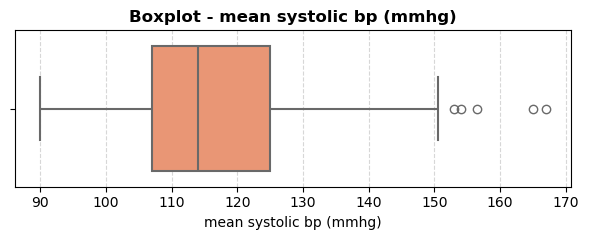

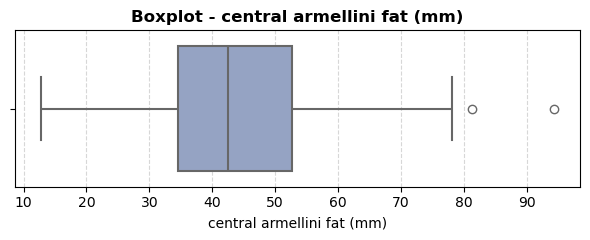

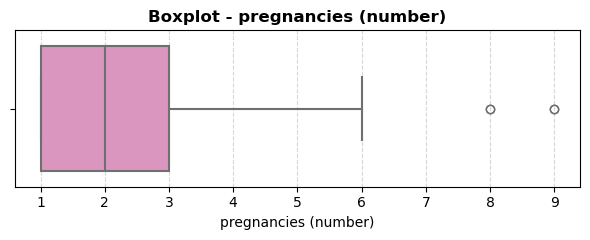

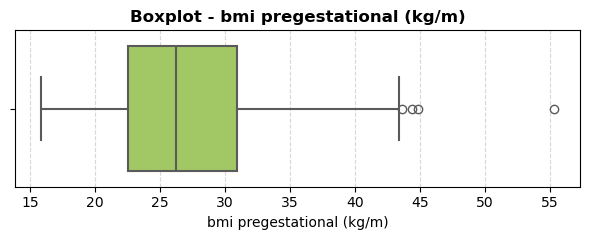

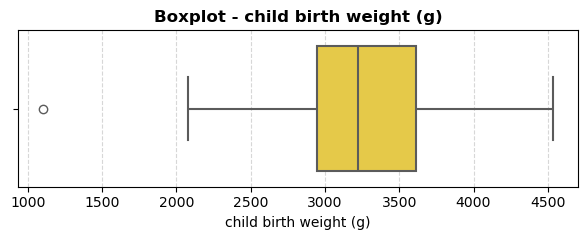

In [4]:
numericas = df.select_dtypes(include=[np.number]).columns

# Excluir variables numéricas que en realidad son categóricas binarias
categorical_numericas = ['ethnicity', 'gestational dm']
numeric_continuous = [col for col in numericas if col not in categorical_numericas and df[col].nunique(dropna=True) > 2]

colores = sns.color_palette("Set2", len(numeric_continuous))

for i, col in enumerate(numeric_continuous):
    plt.figure(figsize=(6,2.5))
    sns.boxplot(
        x=df[col],
        color=colores[i],
        linewidth=1.5
    )
    plt.title(f'Boxplot - {col}', fontsize=12, weight='bold')
    plt.xlabel(col)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

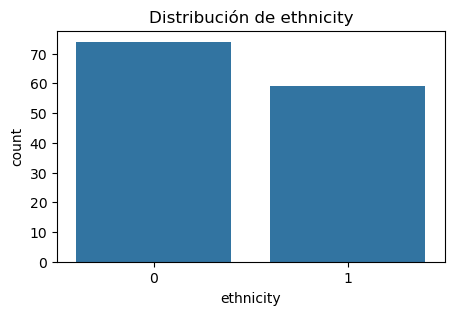

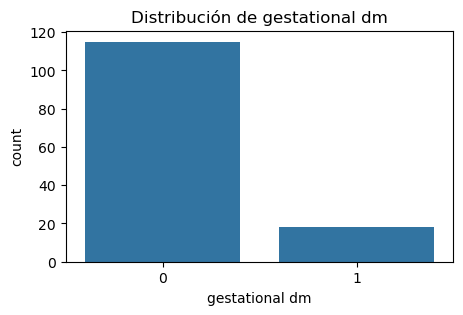

In [5]:
for col in ['ethnicity', 'gestational dm']:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.title(f'Distribución de {col}')
    plt.show()

In [6]:
df.isnull().sum()
df['bmi pregestational (kg/m)'] = df['bmi pregestational (kg/m)'].fillna(df['bmi pregestational (kg/m)'].mean())

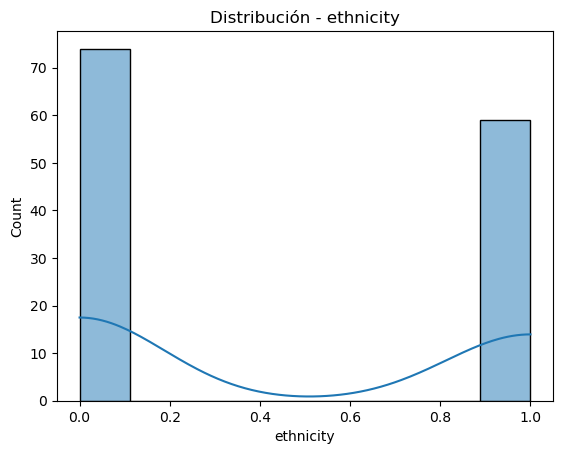

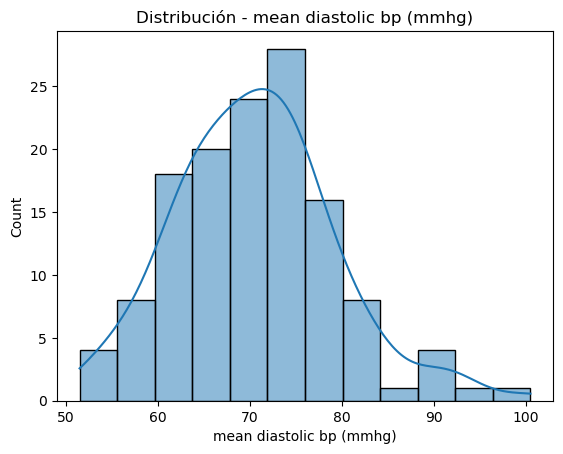

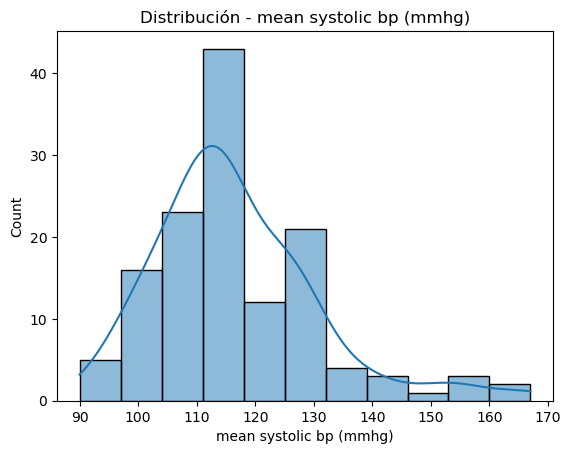

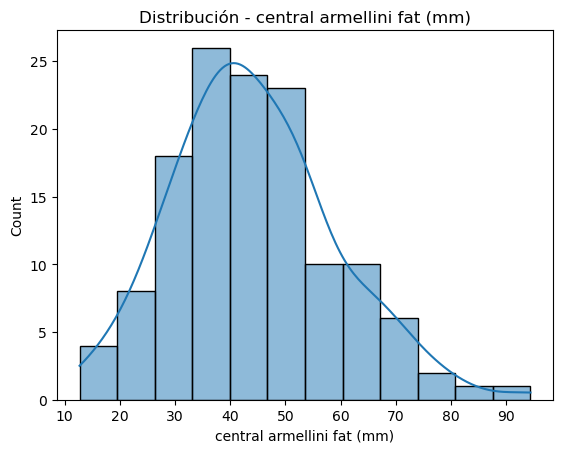

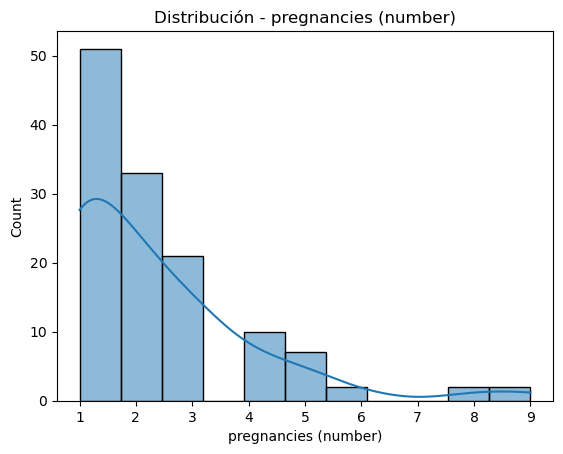

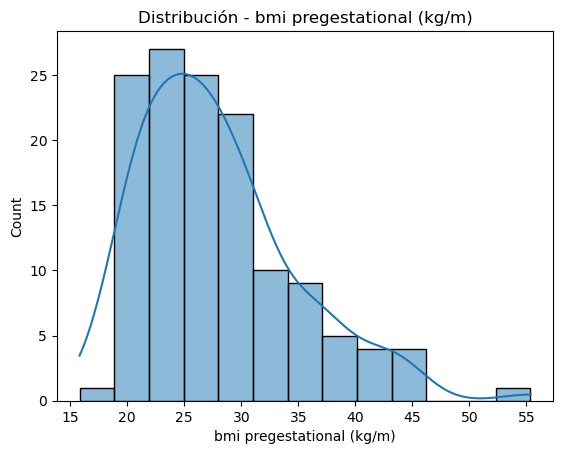

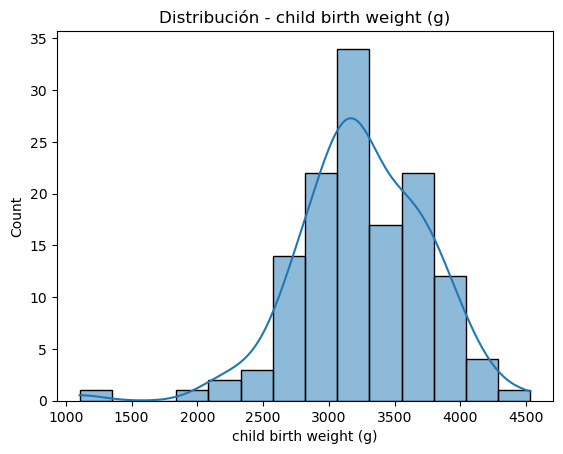

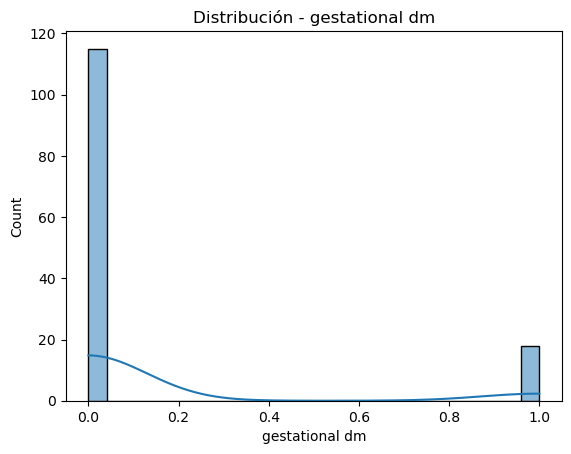

In [7]:
for col in numericas:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución - {col}')
    plt.show()

In [8]:
for col in numericas:
    stat, p = stats.kstest(df[col], 'norm', args=(df[col].mean(), df[col].std()))
    print(col, "p-value:", p)

ethnicity p-value: 8.418993101540925e-17
mean diastolic bp (mmhg) p-value: 0.6399882321482417
mean systolic bp (mmhg) p-value: 0.004880312004145737
central armellini fat (mm) p-value: 0.5705885597297957
pregnancies (number) p-value: nan
bmi pregestational (kg/m) p-value: 0.10331030896294635
child birth weight (g) p-value: 0.688045237189222
gestational dm p-value: 1.087454375216706e-33


Variable normales: t test 

- mean diastolic bp
- central armellini fat
- bmi pregestational
- child birth weight

Variables no normales: U de mann Whitney

- mean systolic bp
- pregnancies

In [9]:
for col in numericas:
    cv = df[col].std() / df[col].mean()
    print(col, "CV:", cv)

ethnicity CV: 1.124161503420653
mean diastolic bp (mmhg) CV: 0.12264022524610928
mean systolic bp (mmhg) CV: 0.1190575308811606
central armellini fat (mm) CV: 0.33022658871897964
pregnancies (number) CV: 0.7171388864738744
bmi pregestational (kg/m) CV: 0.24570865127324878
child birth weight (g) CV: 0.15051694826013245
gestational dm CV: 2.5371814208466756


CV < 0.2 → baja variabilidad

0.2 ≤ CV ≤ 0.5 → variabilidad moderada

CV > 0.5 → alta variabilidad

*Observaciones:*


El número de embarazos destaca por su alta variabilidad, reflejando diferencias importantes entre pacientes. Central armellini fat y bmi pregestational presentan una variabilidad moderada, también hay heterogeneidad moderada entre pacientes. Las variable mean diastolic bp, mean systolic bp y child birth weight presentan baja variabilidad. El coeficiente de variación no es adecuado para variables categóricas como ethnicity y gestational dm porque su media no tiene un significado interpretativo en términos de magnitud.

Las variables con baja variabilidad, como la presión arterial sistólica y diastólica y el peso al nacer, indican que los valores se encuentran relativamente concentrados alrededor de la media; esto sugiere una mayor homogeneidad en la población, esto facilita la comparación entre los grupos y aumenta la estabilidad de estimaciones estadísticas como la media.

Las variables con variabilidad moderada, como el IMC pregestacional y la grasa visceral muestran una heterogeneidad intermedia entre las personas,  esto es esperable en variables biológicas influenciadas por múltiples factores como genéticos, ambientales o de estilo de vida. En estos casos, las comparaciones entre grupos siguen siendo válidas, pero deben interpretarse con mayor cuidado [1].

La presencia de distintos niveles de variabilidad indica que no todas las variables pueden ser tratadas bajo los mismos supuestos estadísticos. En particular, las variables con alta variabilidad o asimetría requieren enfoques más robustos, como transformaciones de los datos o el uso de pruebas no paramétricas, para garantizar la validez de los resultados.


*Observaciones generales:*

Se evidencia que las variables numéricas presentan diferencias importantes en sus escalas, destacándose el peso al nacer como la variable con mayor rango. Además, varias variables muestran indicios de asimetría, particularmente el índice de masa corporal pregestacional, el número de embarazos y la presión arterial sistólica. Esto sugiere que no todas las variables siguen una distribución normal,
Se identificaron valores atípicos en múltiples variables como:
- IMC pregestacional 
- presión arterial 
- número de embarazos 
- peso al nacer

**Tipo de distribución para cada variable**
- mean diastolic bp: Distribución normal, baja variabilidad y un valor p alto 
- child birth weight: distribución proximadamente normal, tiene forma de campana.
- central armellini fat: Distribución muy cercana a normal y más o menos simétrica.
- bmi pregestational: Distribución asimétrica positiva, es decir, se ubserva un sesgo a la derecha.
- mean systolic bp: Distribución asimétrica positiva, cola hacia valores altos.
- pregnancies: Distribución (discreta) asimétrica positiva, se observa concentracion en valores bajos y cola larga.
- Ethnicity y gestational dm son variables categóricas 

El análisis de las distribuciones muestra que solo algunas variables se aproximan a una distribución normal, mientras que otras presentan asimetrías, principalmente hacia la derecha, lo cual es común en variables clínicas [1]. Asimismo, se identificaron variables discretas y categóricas que no siguen distribuciones continuas. Esto es importante para elegir las pruebas 

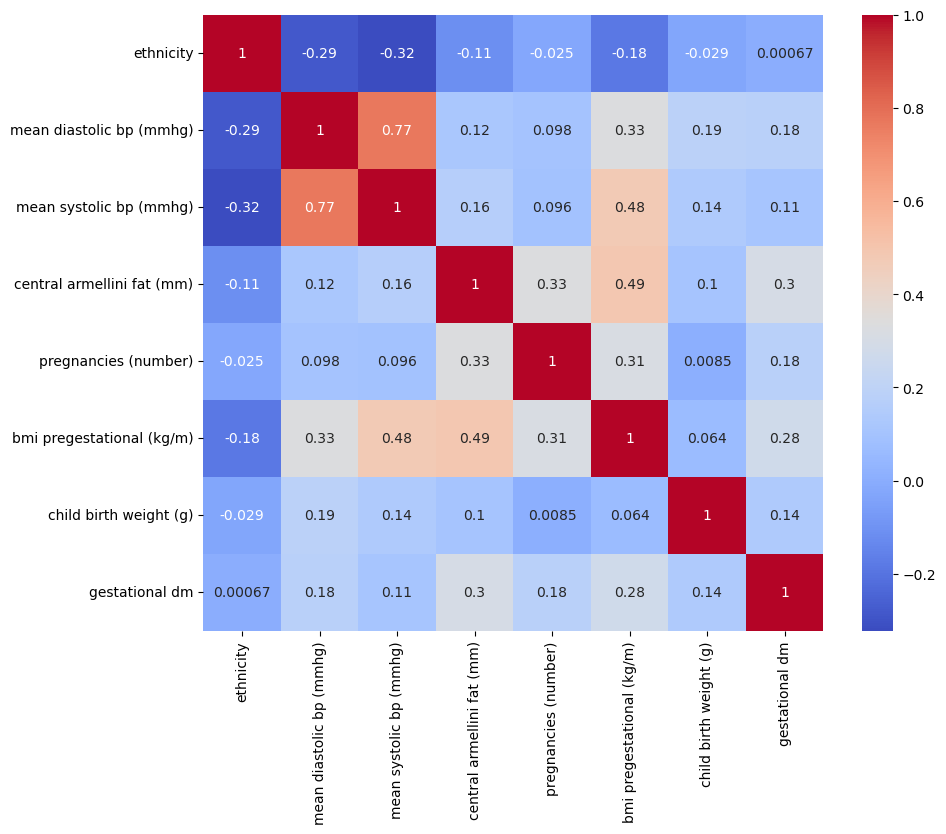

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

*Observaciones:*

- **Presión Arterial Sistólica vs. Diastólica (0.77):** Es la correlación más alta de la matriz, esto es acorde ya que el equilibrio entre estas dos variables determina la presi+on arterial de la persona. 

- **BMI Pregestacional vs. Grasa Central de Armellini (0.49):** Existe una relación moderada-fuerte. Indica que a mayor indice de masa corporal antes del embarazo, mayor es la acumulación de grasa visceral medida por ultrasonido.

- **Diabetes Gestacional con Grasa de Armellini (0.3) y BMI (0.28):** Estas variables muestran una relación positiva con la presencia de diabetes. La obesidad pregestacional y la grasa visceral son factores de riesgo críticos para el desarrollo de resistencia a la insulina durante el embarazo [2][3].

- **Embarazos (Pregnancies) y BMI/Grasa (0.31 - 0.33):** Se observa que a mayor número de embarazos, tienden a subir estos indicadores. Esto se asocia frecuentemente con la retención de peso postparto acumulada en gestaciones posteriores [4].

- **Etnia y Diabetes Gestacional (0.00067):** Este valor es prácticamente cero. Indica que en este grupo de datos específico, pertenecer a una etnia u otra no influye en absoluto en el riesgo de diabetes.

*Variables categóricas:*
- Ethnicity:

Tipo de Variable: Categórica Nominal Binaria

Distribución: Muestra un comportamiento bimodal, los datos se concentran en los extremos 0.0 y 1.0

- Gestational DM:

Tipo de Variable: Categórica Nominal Binaria

Distribución: Presenta un fuerte desbalance de clases. La gran mayoría de los indivios se encuentran en la categoría 0 (más de 110 casos), mientras que una minoría presenta la condición 1 (menos de 20 casos).




**Referencias**

[1] Nandy, A., Basu, A., & Ghosh, A. (2021). Robust inference for skewed data in health sciences. Journal Of Applied Statistics, 49(8), 2093-2123. https://doi.org/10.1080/02664763.2021.1891527

[2] Kampmann, U., Ovesen, P. G., Møller, N., & Fuglsang, J. (2021). Extreme insulin resistance during pregnancy: a therapeutic challenge. Endocrinology, diabetes & metabolism case reports, 2021, 20-0191. Advance online publication. https://doi.org/10.1530/EDM-20-0191

[3] Luis, B. R. J., & Blas, H. V. (2016). Medición ultrasonográfica de la grasa visceral y su asociación con factores de riesgo cardiovasculares y metabólicos en restantes con sobrepeso. Dialnet. https://dialnet.unirioja.es/servlet/tesis?codigo=50779 

[4] Torres, L., Fotia Perniciaro, L. M. R., Mendez, I., Malpeli, A., & Kruger, A. L. (2025). Factores asociados a la retención de peso postparto en mujeres que asisten a un hospital público de la Provincia de Buenos Aires [Factors associated with postpartum weight retention in women attending a public hospital in the Province of Buenos Aires]. Revista de la Facultad de Ciencias Medicas (Cordoba, Argentina), 82(2), 271–286. https://doi.org/10.31053/1853.0605.v82.n2.45625



**Étnia**

Se selecciona la prueba T de muuestras independeintes porque se desea comparar la media de una variable numérica entre dos grupos independientes definidos por la variable Ethnicity 

H0: No existen diferencias en la media de la presión sistólica entre mujeres blancas y no blancas.

H1: Existen diferencias en la media de la presión sistólica entre mujeres blancas y no blancas.

*Verificación de supuestos*

Normalidad (Kolmogorov–Smirnov):

- H0: Los datos siguen distribución normal
- H1: Los datos no siguen distribución normal

Homocedasticidad (Levene)

- H0: Las varianzas son iguales
- H1: Las varianzas son diferentes

In [11]:
from scipy import stats
import numpy as np

variable = 'mean systolic bp (mmhg)' 

g1 = df[df['ethnicity'] == 0][variable].dropna()
g2 = df[df['ethnicity'] == 1][variable].dropna()

# Kolmogorov-Smirnov
m1, s1 = np.mean(g1), np.std(g1, ddof=1)
m2, s2 = np.mean(g2), np.std(g2, ddof=1)

ks1 = stats.kstest(g1, 'norm', args=(m1, s1))
ks2 = stats.kstest(g2, 'norm', args=(m2, s2))

print("KS grupo 0:", ks1)
print("KS grupo 1:", ks2)

# Levene
lev = stats.levene(g1, g2)
print("Levene:", lev)

KS grupo 0: KstestResult(statistic=np.float64(0.15275838338708925), pvalue=np.float64(0.05666918370507512), statistic_location=np.float64(116.5), statistic_sign=np.int8(1))
KS grupo 1: KstestResult(statistic=np.float64(0.13369267576161648), pvalue=np.float64(0.22155611384549245), statistic_location=np.float64(116.0), statistic_sign=np.int8(1))
Levene: LeveneResult(statistic=np.float64(0.8986435504309129), pvalue=np.float64(0.344891137673057))


*Grupo 1*

p-value = 0.0567
- p > 0.05 → no se rechaza H0. Los datos siguen distribución normal

*Grupo 2*

p-value = 0.2216
- p > 0.05 → no se rechaza H0. Los datos siguen distribución normal

*Homocedasticidad*

p-value = 0.3449
- p > 0.05 → no se rechaza H0. Las varianzas son iguales.

Se cumple normalidad en ambos grupos y hay igualdad de varianzas, por lo que se confirma que se utiliza la prueba t para muestras independientes.

In [12]:
stat, p = stats.ttest_ind(g1, g2)
print("p-value:", p)

p-value: 0.00015739776730255335


*Resultado:* p < 0.05. Se rechaza la hipótesis nula (H0).

Debido a que se cumplieron los supuestos de normalidad y homocedasticidad, se aplicó la prueba t para muestras independientes. El valor p obtenido (p = 0.000157) fue menor al nivel de significancia establecido (α = 0.05), lo que indica evidencia estadísticamente significativa para afirmar que existen diferencias en la media de la variable analizada entre mujeres blancas y no blancas. Esto indica que la etnia podría estar relacionada con variaciones en esta característica.

**Hipótesis por variable**

*Presión diastólica*
- H0: No existen diferencias en la media de la presión diastólica entre mujeres blancas y no blancas.
- H1: Existen diferencias en la media de la presión diastólica entre mujeres blancas y no blancas.

*Presión sistólica*
- H0: No existen diferencias en la media de la presión sistólica entre mujeres blancas y no blancas.
- H1: Existen diferencias en la media de la presión sistólica entre mujeres blancas y no blancas.

*Grasa visceral*
- H0: No existen diferencias en la media de la grasa visceral entre mujeres blancas y no blancas.
- H1: Existen diferencias en la media de la grasa visceral entre mujeres blancas y no blancas.

*Número de embarazos*
- H0: No existen diferencias en el número de embarazos entre mujeres blancas y no blancas.
- H1: Existen diferencias en el número de embarazos entre mujeres blancas y no blancas.

*IMC pregestacional*
- H0: No existen diferencias en el IMC pregestacional entre mujeres blancas y no blancas.
- H1: Existen diferencias en el IMC pregestacional entre mujeres blancas y no blancas.

*Peso al nacer*
- H0: No existen diferencias en el peso al nacer entre mujeres blancas y no blancas.
- H1: Existen diferencias en el peso al nacer entre mujeres blancas y no blancas.

In [13]:
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest 
from statsmodels.stats.multitest import multipletests 

def numero_datos(tabla1,tabla2,variable):
    print(len(tabla1[variable])) 
    print(len(tabla2[variable]))


def Prueba_de_normalidad_kolmogorov(tabla1,tabla2,variable):
    #Normalidad para grupo blancas
    _, ks_p1 = stats.kstest(tabla1[variable], 'norm', args=(np.mean(tabla1[variable]), np.std(tabla1[variable])))
    print(f"{ks_p1}")

    #normalidad para grupo no blancas
    _, ks_p2 = stats.kstest(tabla2[variable], 'norm', args=(np.mean(tabla2[variable]), np.std(tabla2[variable])))
    print(f"{ks_p2}")

    if ks_p1 > 0.05 and ks_p2 > 0.05:
        print("Ambos grupos siguen una distribución normal.")
    else:
        print("Al menos uno de los grupos no sigue una distribución normal.")


In [14]:
grupo_blancas = df[df['ethnicity'] == 0]
grupo_no_blancas = df[df['ethnicity'] == 1]

grupo_blancas.head()

,ethnicity,mean diastolic bp (mmhg),mean systolic bp (mmhg),central armellini fat (mm),pregnancies (number),bmi pregestational (kg/m),child birth weight (g),gestational dm
1,0,75.5,112.0,43.1,1.0,21.50,2810,0
3,0,92.5,167.0,39.6,4.0,55.36,3400,0
5,0,67.5,111.5,26.8,1.0,22.60,2730,0
6,0,72.0,132.0,39.9,1.0,37.18,3615,0
9,0,90.0,126.5,25.8,2.0,25.71,3845,0


In [15]:
grupo_no_blancas.head()

,ethnicity,mean diastolic bp (mmhg),mean systolic bp (mmhg),central armellini fat (mm),pregnancies (number),bmi pregestational (kg/m),child birth weight (g),gestational dm
0,1,73.5,125.0,28.1,1.0,33.20,3840,0
2,1,70.5,116.0,41.4,1.0,21.41,2455,0
4,1,79.0,137.0,67.8,2.0,30.85,3930,1
7,1,74.5,114.0,20.6,1.0,19.66,3610,0
8,1,59.5,96.5,21.1,1.0,15.81,3460,0


In [16]:
var = 'mean diastolic bp (mmhg)'
numero_datos(grupo_blancas,grupo_no_blancas,var)

74
59


In [17]:
Prueba_de_normalidad_kolmogorov(grupo_blancas,grupo_no_blancas,var)
stat, p_value = stats.bartlett(grupo_blancas[var], grupo_no_blancas[var])
print(f"p-value: {p_value}")

0.44607254304697475
0.9050620889244742
Ambos grupos siguen una distribución normal.
p-value: 0.4295399398316261


In [18]:
t_stat, p_value = stats.ttest_ind(grupo_blancas[var], grupo_no_blancas[var])
print(f"El valor p es: {p_value}")

El valor p es: 0.0008760029941810939


PARTE DIEGO 

 Para cada variable numérica, determine si existe diferencia estadística 
entre: mujeres blancas y no blancas, primíparas y multíparas, y mujeres con 
diabetes gestacional o no.  Para esto deberá separar el DataFrame en dos 
para cada comparación pedida según la variable indicada previamente 
(blancas o no, primíparas o no…). Se espera que realicen los análisis 
comparativos de forma separada, es decir, primero se debe hacer el análisis 
completo entre mujeres blancas y no blancas, luego el siguiente y así 
sucesivamente, para cada análisis comparativo pedido se pide lo siguiente 
(cada ítem desarróllelo de forma separada, bien sea en código seguido de 
celda de texto, o solo en celda de texto según corresponda) 

ANALISIS PRIMIPARAS Y MULTIPARAS 

In [20]:
df = pd.read_excel("visceral_fat.xlsx")     
print(df['pregnancies (number)'].isnull().sum())
# Se procede a eliminar las filas con valores nulos en la columna 'pregnancies (number)'
df = df.dropna(subset=['pregnancies (number)'])
print(df['pregnancies (number)'].isnull().sum())


5
0


In [21]:
# Ahora se procede a separar dos grupos las que tienen mas de un hijo es decir las multíparas y las que tienen un hijo (Primiparas)
df_multiparas = df[df['pregnancies (number)'] > 1] 
df_primiparas = df[df['pregnancies (number)'] == 1]

# conteo de cuantas mujeres hay en df_multiparas y df_primiparas
print("Número de mujeres multíparas:", len(df_multiparas))
print("Número de mujeres primíparas:", len(df_primiparas))
df_multiparas.head()



Número de mujeres multíparas: 77
Número de mujeres primíparas: 51


,ethnicity,mean diastolic bp (mmhg),mean systolic bp (mmhg),central armellini fat (mm),pregnancies (number),bmi pregestational (kg/m),child birth weight (g),gestational dm
3,0,92.5,167.0,39.6,4.0,55.36,3400,0
4,1,79.0,137.0,67.8,2.0,30.85,3930,1
9,0,90.0,126.5,25.8,2.0,25.71,3845,0
11,1,62.0,117.5,46.7,2.0,30.82,3200,0
12,1,62.5,97.5,30.4,2.0,19.43,3275,0


In [30]:


# Variables numéricas continuas (las que ya venías filtrando)
numericas = df.select_dtypes(include=[np.number]).columns

variables_excluir = ['pregnancies (number)']

numeric_continuous = [
    col for col in numericas
    if col not in categorical_numericas
    and col not in variables_excluir
    and df[col].nunique(dropna=True) > 2
]

print("\nPRUEBAS DE NORMALIDAD (Kolmogorov-Smirnov)\n")

for col in numeric_continuous:
    print(f"\nVARIABLE: {col}")
    
    # ===== PRIMÍPARAS =====
    data1 = df_primiparas[col].dropna()
    
    if len(data1) >= 3:
        m1, s1 = np.mean(data1), np.std(data1, ddof=1)
        ks1 = stats.kstest(data1, 'norm', args=(m1, s1))
        res1 = 'NORMAL' if ks1.pvalue >= 0.05 else 'NO NORMAL'
        print(f"  Primíparas: {res1} (p = {ks1.pvalue:.4f})")
    else:
        print("  Primíparas: datos insuficientes")

    # ===== MULTÍPARAS =====
    data2 = df_multiparas[col].dropna()
    
    if len(data2) >= 3:
        m2, s2 = np.mean(data2), np.std(data2, ddof=1)
        ks2 = stats.kstest(data2, 'norm', args=(m2, s2))
        res2 = 'NORMAL' if ks2.pvalue >= 0.05 else 'NO NORMAL'
        print(f"  Multíparas: {res2} (p = {ks2.pvalue:.4f})")
    else:
        print("  Multíparas: datos insuficientes")



# H0: los datos siguen una distribución normal.
# H1: los datos no siguen una distribución normal.
# Si p-value < 0.05, se rechaza H0 y se acepta H1.
# El resultado impreso indica cuáles variables se consideran normales y cuáles no, para primíparas y multíparas.




PRUEBAS DE NORMALIDAD (Kolmogorov-Smirnov)


VARIABLE: mean diastolic bp (mmhg)
  Primíparas: NORMAL (p = 0.8128)
  Multíparas: NORMAL (p = 0.9534)

VARIABLE: mean systolic bp (mmhg)
  Primíparas: NORMAL (p = 0.1187)
  Multíparas: NO NORMAL (p = 0.0361)

VARIABLE: central armellini fat (mm)
  Primíparas: NORMAL (p = 0.7520)
  Multíparas: NORMAL (p = 0.9589)

VARIABLE: bmi pregestational (kg/m)
  Primíparas: NORMAL (p = 0.4044)
  Multíparas: NORMAL (p = 0.4518)

VARIABLE: child birth weight (g)
  Primíparas: NORMAL (p = 0.6890)
  Multíparas: NORMAL (p = 0.4414)


In [32]:

variable = 'mean systolic bp (mmhg)'

# datos multíparas (porque es NO normal en tu resultado)
data = df_multiparas[variable].dropna()

# asegurar valores positivos (Box-Cox lo requiere)
if (data <= 0).any():
    data = data + abs(data.min()) + 1

# aplicar Box-Cox
transformed_data, lambda_bc = stats.boxcox(data)

print("Lambda:", lambda_bc)

ks = stats.kstest(
    transformed_data,
    'norm',
    args=(np.mean(transformed_data), np.std(transformed_data))
)

print("Después de Box-Cox:")
print("p-value:", ks.pvalue)
print("Conclusión:", "NORMAL" if ks.pvalue >= 0.05 else "NO NORMAL")

Lambda: -2.172281811025519
Después de Box-Cox:
p-value: 0.5500791685015706
Conclusión: NORMAL


In [33]:
variables = [
    'mean diastolic bp (mmhg)',
    'mean systolic bp (mmhg)',
    'central armellini fat (mm)',
    'bmi pregestational (kg/m)',
    'child birth weight (g)'
]

print("\nPRUEBA DE LEVENE (HOMOCEDASTICIDAD)\n")

for col in variables:
    
    g1 = df_primiparas[col].dropna()
    g2 = df_multiparas[col].dropna()
    
    stat, p = stats.levene(g1, g2)
    
    conclusion = "HOMOCEDÁSTICAS" if p >= 0.05 else "NO HOMOCEDÁSTICAS"
    
    print(f"{col}: {conclusion} (p = {p:.4f})")


PRUEBA DE LEVENE (HOMOCEDASTICIDAD)

mean diastolic bp (mmhg): HOMOCEDÁSTICAS (p = 0.2301)
mean systolic bp (mmhg): HOMOCEDÁSTICAS (p = 0.4014)
central armellini fat (mm): NO HOMOCEDÁSTICAS (p = 0.0264)
bmi pregestational (kg/m): NO HOMOCEDÁSTICAS (p = 0.0061)
child birth weight (g): HOMOCEDÁSTICAS (p = 0.4550)


In [ ]:
# VARIABLE: mean diastolic bp (mmhg)
# Primíparas: NORMAL (p = 0.8128)
# Multíparas: NORMAL (p = 0.9534)
# AMBOS GRUPOS SON HOMOCEDÁSTICOS (p = 0.2301)


g1 = df_primiparas['mean diastolic bp (mmhg)'].dropna()
g2 = df_multiparas['mean diastolic bp (mmhg)'].dropna()

stat, p = stats.ttest_ind(g1, g2, equal_var=True)

print("t-test Student")
print("p-value:", p)
print("Conclusión:", "DIFERENCIA SIGNIFICATIVA" if p < 0.05 else "NO SIGNIFICATIVA")

# H0: no hay diferencia en la media de la presión diastólica entre primíparas y multíparas.
# H1: hay una diferencia en la media de la presión diastólica entre primíparas y multíparas.


t-test Student
p-value: 0.17295380827024917
Conclusión: NO SIGNIFICATIVA


In [35]:
# VARIABLE: mean systolic bp (mmhg)
# Primíparas: NORMAL (p = 0.1187)
# Multíparas: NO NORMAL (p = 0.0361)
# AMBOS GRUPOS NO SON HOMOCEDÁSTICOS (p = 0.4014)

from scipy import stats

g1 = df_primiparas['mean systolic bp (mmhg)'].dropna()
g2 = df_multiparas['mean systolic bp (mmhg)'].dropna()

stat, p = stats.ttest_ind(g1, g2, equal_var=True)

print("t-test de Student (post Box-Cox)")
print("p-value:", p)
print("Conclusión:", "DIFERENCIA SIGNIFICATIVA" if p < 0.05 else "NO SIGNIFICATIVA")

t-test de Student (post Box-Cox)
p-value: 0.4192878045319015
Conclusión: NO SIGNIFICATIVA


In [36]:
# VARIABLE: central armellini fat (mm)
# Primíparas: NORMAL (p = 0.7520)
# Multíparas: NORMAL (p = 0.9589)
# NO TIENEN HOMOCEDASTICIDAD (p = 0.0264)


g1 = df_primiparas['central armellini fat (mm)'].dropna()
g2 = df_multiparas['central armellini fat (mm)'].dropna()

stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')

print("Mann-Whitney U test")
print("p-value:", p)
print("Conclusión:", "DIFERENCIA SIGNIFICATIVA" if p < 0.05 else "NO SIGNIFICATIVA")

Mann-Whitney U test
p-value: 0.0001784754437100851
Conclusión: DIFERENCIA SIGNIFICATIVA


In [37]:
# VARIABLE: bmi pregestational (kg/m)
# Primíparas: NORMAL (p = 0.4044)
# Multíparas: NORMAL (p = 0.4518)
# NO TIENEN HOMOCEDASTICIDAD (p = 0.0061)

g1 = df_primiparas['bmi pregestational (kg/m)'].dropna()
g2 = df_multiparas['bmi pregestational (kg/m)'].dropna()

stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')

print("Mann-Whitney U test")
print("p-value:", p)
print("Conclusión:", "DIFERENCIA SIGNIFICATIVA" if p < 0.05 else "NO SIGNIFICATIVA")

Mann-Whitney U test
p-value: 0.0019617442504546883
Conclusión: DIFERENCIA SIGNIFICATIVA


In [39]:
#VARIABLE: child birth weight (g)
# Primíparas: NORMAL (p = 0.6890)
# Multíparas: NORMAL (p = 0.4414)
# TIENEN HOMOCEDASTICIDAD (p = 0.4550)

g1 = df_primiparas['child birth weight (g)'].dropna()
g2 = df_multiparas['child birth weight (g)'].dropna()

stat, p = stats.ttest_ind(g1, g2, equal_var=True)

print("t-test de Student")
print("p-value:", p)
print("Conclusión:", "DIFERENCIA SIGNIFICATIVA" if p < 0.05 else "NO SIGNIFICATIVA")


t-test de Student
p-value: 0.07933906004948288
Conclusión: NO SIGNIFICATIVA
